🧠 Big Idea: Why Model Diagnostics Matter

👉 You built a regression model.
👉 It gives results.

But the real question is:

❗ “Can I TRUST this model?”

🏥 Simple Clinical Story

Imagine:

Model says:
👉 “Higher drug dose → shorter hospital stay”

But in reality:

Very high doses may cause complications ❗

👉 If you don’t check assumptions → you may make wrong clinical decisions

🔍 What are we checking?

We check if the model assumptions match real-world data

🧩 1. Residuals (MOST IMPORTANT)
🧠 What is a residual?

👉 Residual =
Actual value − Predicted value

📊 Good Model Pattern

👉 Residuals should look like:

Random scatter
No pattern

✅ Means: model fits well

🚨 Bad Pattern 1: Curve (Nonlinearity)

👉 Example:

Age vs Length of stay is curved
But model assumes straight line

❗ Problem:

Model is too simple

👉 Fix:

Add polynomial (Age²)
Or use different model
🧠 Easy intuition:

If residuals show pattern → model is wrong

📉 2. Heteroscedasticity (Unequal spread)
🧠 What it means:

👉 Errors are not consistent

Example:

Short stays → small error
Long stays → BIG error
📊 Pattern:

👉 Funnel shape 🔺

🚨 Why problem?
Model is less reliable for some patients
✅ Fix:
Log transformation
Weighted regression
🧩 3. Outliers
🧠 Example:
Most patients stay: 3–7 days
One patient: 90 days
🚨 Problem:
Outlier can pull the regression line
Wrong conclusions
✅ What to do:
Investigate (real or error?)
Remove OR use robust methods
🧩 4. Multicollinearity (Hidden danger ⚠️)
🧠 What it means:

👉 Predictors are too similar

Example:

Age
Number of diseases

👉 Both increase together

🚨 Problem:

Model gets confused:

“Who is really responsible?”

👉 Coefficients become unstable

📏 Tool: VIF (Variance Inflation Factor)
VIF	Meaning
< 5	OK
> 10	Problem 🚨
✅ Fix:
Remove one variable
Combine variables
🎯 Summary Table (VERY IMPORTANT)
Problem	What you see	Meaning	Fix
Nonlinearity	Curve in residuals	Wrong model form	Add curve / transform
Heteroscedasticity	Funnel shape	Unequal errors	Log transform
Outliers	Extreme points	Distortion	Investigate/remove
Multicollinearity	High VIF	Predictors overlap	Remove/combine
🧠 Clinical Interpretation

👉 You don’t just say:

❌ “Model is significant”

👉 You say:

✅ “Model is reliable and assumptions are valid”

🚨 Key Insight (VERY IMPORTANT)

A model can have a LOW p-value and still be WRONG

👉 That’s why diagnostics are critical

🧭 Easy Memory Trick

Before trusting regression, always ask:

👉 “Does my model behave well?”

Check:

Residuals → random?
Spread → constant?
Outliers → extreme?
Predictors → independent?
⭐ Final Takeaway

**Let’s walk through a complete beginner-friendly clinical **

In [ ]:
Step 0: Clinical Scenario

👉 “Predict hospital stay (days) using:

Age
Number of comorbidities
Medication dose”
❌ Step 1: Build a BAD model
🔹 What this code does
Creates toy clinical data
Fits a regression model
This model will intentionally violate assumptions
🔹 Why we do this

👉 To see problems first, then learn how to fix them


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Toy clinical data
np.random.seed(0)

age = np.random.randint(30, 80, 20)
comorbidity = np.random.randint(1, 5, 20)

# BAD: nonlinear + heteroscedastic + outlier
stay = 2 + 0.05*(age**1.5) + 2*comorbidity + np.random.normal(0, 5, 20)
stay[0] = 120  # extreme outlier

df = pd.DataFrame({
    'age': age,
    'comorbidity': comorbidity,
    'stay': stay
})

# Regression
X = df[['age', 'comorbidity']]
X = sm.add_constant(X)
model = sm.OLS(df['stay'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   stay   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     5.086
Date:                Tue, 07 Apr 2026   Prob (F-statistic):             0.0186
Time:                        12:59:26   Log-Likelihood:                -86.403
No. Observations:                  20   AIC:                             178.8
Df Residuals:                      17   BIC:                             181.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -14.4456     17.884     -0.808      

🧠 Pattern to learn

👉 Regression always follows this structure:
1. Define X (predictors)
2. Add constant
3. Fit model
4. Print summary

Step 2: Check Residual Plot (Problem Detection)
🔹 What this code does
Plots errors (residuals)
Helps detect:
Non-linearity
Unequal variance
🔹 Why

👉 Residuals tell us if model assumptions are broken

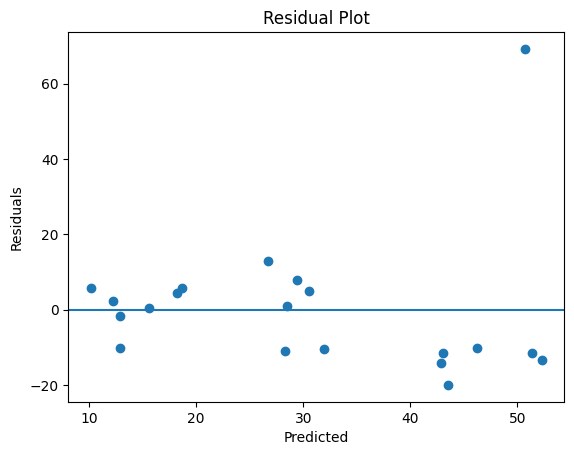

In [2]:
import matplotlib.pyplot as plt

pred = model.predict(X)
residuals = df['stay'] - pred

plt.scatter(pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

What you’ll see (interpretation)

❌ Problems:

Curve shape → non-linearity
Funnel shape → heteroscedasticity
One extreme point → outlier

👉 So model is NOT reliable

Step 3: Check Multicollinearity (VIF)
🔹 What this code does
Checks if predictors are too correlated

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

       feature        VIF
0        const  16.421987
1          age   1.000006
2  comorbidity   1.000006


🧠 Pattern to remember
Loop through each column → compute VIF

👉 Rule:

VIF < 5 → OK
VIF > 10 → BAD

Step 4: Fix the Model (Step-by-Step)

Fix 1: Remove Outlier
🔹 Why

Outliers distort regression

In [4]:
df_clean = df[df['stay'] < 100]

Fix 2: Fix Non-linearity (Transform variable)

👉 Problem: age effect is curved

👉 Solution: log or sqrt transform

In [5]:
df_clean['age_sqrt'] = np.sqrt(df_clean['age'])

/tmp/ipykernel_12064/799922114.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['age_sqrt'] = np.sqrt(df_clean['age'])


Fix 3: Rebuild Model

In [6]:
X2 = df_clean[['age_sqrt', 'comorbidity']]
X2 = sm.add_constant(X2)

model2 = sm.OLS(df_clean['stay'], X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   stay   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     21.95
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           2.59e-05
Time:                        13:06:36   Log-Likelihood:                -59.192
No. Observations:                  19   AIC:                             124.4
Df Residuals:                      16   BIC:                             127.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -34.4226      9.322     -3.693      

🧠 Pattern

👉 Fix model =

Clean data → transform → rebuild model

Step 5: Check Residuals Again

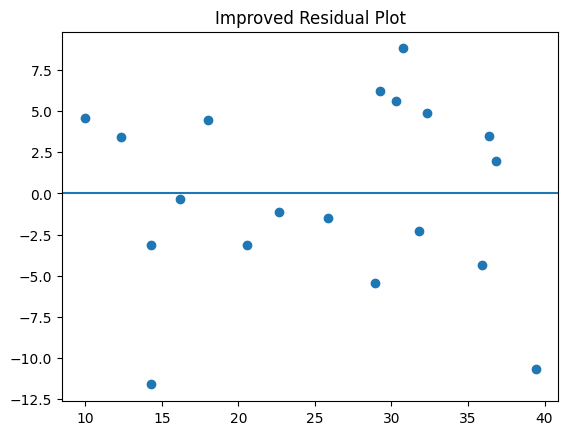

In [7]:
pred2 = model2.predict(X2)
residuals2 = df_clean['stay'] - pred2

plt.scatter(pred2, residuals2)
plt.axhline(0)
plt.title("Improved Residual Plot")
plt.show()

What you expect now

✅ Residuals randomly scattered
✅ No curve
✅ No funnel

👉 Model assumptions now valid

Final Summary (Very Important)
❌ Bad Model Issues
Non-linearity ❌
Heteroscedasticity ❌
Outlier ❌
✅ Fix Strategy (Golden Rule)
1. Check residuals
2. Remove outliers
3. Transform variables
4. Refit model
5. Recheck diagnostics
🧠 Intuition (This is what experts think)

👉 Regression is NOT:

“Run once and trust output”

👉 It IS:

“Build → check → fix → repeat”